<a href="https://colab.research.google.com/github/Potahati/inria-building-unet/blob/main/2_data_pipeline_mvp_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#from google.colab import drive

In [ ]:
#drive.mount('/content/drive')

Mounted at /content/drive


Инициализация класса InriaDataset

In [ ]:
import os
import cv2
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

class InriaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Чтение трехканального спутникового снимка
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Чтение одноканальной маски застройки
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Перевод маски в бинарный формат (0 или 1)
        mask = (mask > 127).astype(np.float32)

        # Синхронное применение кадрирования и нормализации
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Добавление канала размерности для PyTorch, чтобы получить [1, H, W]
        if isinstance(mask, torch.Tensor):
            mask = mask.unsqueeze(0)
        else:
            mask = np.expand_dims(mask, axis=0)

        return image, mask

# Подготовка путей к локальным файлам в Colab
dataset_dir = Path('/content/drive/MyDrive/Inria_Project/unzip_full_archive/train')
images_dir = dataset_dir / 'images'
masks_dir = dataset_dir / 'gt'

# Сбор путей и обязательная жесткая сортировка для исключения рассинхронизации
all_img_paths = sorted([str(p) for p in images_dir.iterdir() if p.is_file()])
all_msk_paths = sorted([str(p) for p in masks_dir.iterdir() if p.is_file()])

# Разделение папки train на изолированное обучение и валидацию (85% на 15%)
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    all_img_paths,
    all_msk_paths,
    test_size=0.15,
    random_state=42
)

# Определение трансформаций для обучения (случайный кроп 512x512)
train_transform = A.Compose([
    A.RandomCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Определение трансформаций для валидации (фиксированный центральный кроп)
val_transform = A.Compose([
    A.CenterCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Создание экземпляров класса Dataset для обоих потоков
train_dataset = InriaDataset(image_paths=train_imgs, mask_paths=train_msks, transform=train_transform)
val_dataset = InriaDataset(image_paths=val_imgs, mask_paths=val_msks, transform=val_transform)

# Финальное создание загрузчиков батчей для нейросети
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=False)

# Проверочный прогон для подтверждения работоспособности пайплайна
test_images, test_masks = next(iter(train_loader))
print(f"Успех! Размерность батча изображений: {test_images.shape}")
print(f"Успех! Размерность батча масок: {test_masks.shape}")

Успех! Размерность батча изображений: torch.Size([4, 3, 512, 512])
Успех! Размерность батча масок: torch.Size([4, 1, 512, 512])


### **Получение тестового и валидационного множества**

тут разбирается, как нарезаются исходные изображения большого размера(заливка их в модель вызовет ошибку out of memory) на подходящие снимки.

In [ ]:
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Фиксируем пути к локальным директориям
dataset_dir = Path('/content/drive/MyDrive/Inria_Project/unzip_full_archive/train')
images_dir = dataset_dir / 'images'
masks_dir = dataset_dir / 'gt'

# Собираем файлы и применяем строгую сортировку для идеального маппинга
all_img_paths = sorted([str(p) for p in images_dir.iterdir() if p.is_file()])
all_msk_paths = sorted([str(p) for p in masks_dir.iterdir() if p.is_file()])

# Разделяем пути на train и val в пропорции 85/15 с фиксацией случайного сида
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    all_img_paths,
    all_msk_paths,
    test_size=0.15,
    random_state=42
)

# Для обучающей выборки используем случайное кадрирование и нормализацию
train_transform = A.Compose([
    A.RandomCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Для валидационной выборки используем центральное кадрирование, чтобы оценка была стабильной
val_transform = A.Compose([
    A.CenterCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Инициализируем два отдельных экземпляра класса Dataset
train_dataset = InriaDataset(image_paths=train_imgs, mask_paths=train_msks, transform=train_transform)
val_dataset = InriaDataset(image_paths=val_imgs, mask_paths=val_msks, transform=val_transform)

# Создаем финальные DataLoader. Для валидации перемешивание (shuffle) не требуется
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=False)

print(f"Количество снимков для обучения: {len(train_imgs)}")
print(f"Количество снимков для валидации: {len(val_imgs)}")

Количество снимков для обучения: 153
Количество снимков для валидации: 27


In [ ]:
!pip install segmentation_models_pytorch

Инициализация модели Unet с базовыми весами(до обучения)

In [ ]:
import torch
import segmentation_models_pytorch as smp

# 1. Определение устройства вычислений
# Обязательно убедись, что в Colab включен GPU (Среда выполнения -> Сменить среду выполнения -> T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# 2. Инициализация модели U-Net
model = smp.Unet(
    encoder_name='resnet34',        # Легкий и эффективный энкодер
    encoder_weights='imagenet',     # Предобученные веса для быстрого схождения
    in_channels=3,                  # Количество каналов на входе (RGB снимки)
    classes=1                       # Количество каналов на выходе (бинарная маска)
)

# Перенос весов модели в память видеокарты
model = model.to(device)

Обучающий цикл(3 эпохи)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# Настройка компонентов обучения
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Задаем базовое количество эпох для MVP
num_epochs = 3

train_losses = []
val_losses = []

print("Запуск тренировочного цикла на GPU...")

for epoch in range(num_epochs):

    # Фаза 1: Обучение модели
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Обучение]")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_bar.set_postfix({'loss': loss.item()})

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Фаза 2: Валидация модели
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Валидация]")
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()
            val_bar.set_postfix({'val_loss': loss.item()})

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Итог эпохи {epoch+1}: Train Loss = {epoch_train_loss:.4f} | Val Loss = {epoch_val_loss:.4f}\n")

# Фиксация промежуточного результата на Диске
torch.save(model.state_dict(), '/content/unet_resnet34_inria.pth')
print("Обучение завершено. Файл весов упешно сохранен на локальный диск.")

Обучающий цикл(30 эпох)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import math # Импортируем модуль для обозначения бесконечности

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30
train_losses = []
val_losses = []

# Инициализируем переменную для хранения рекорда ошибки
best_val_loss = math.inf

print("Запуск тренировочного цикла на GPU...")

for epoch in range(num_epochs):

    # Фаза 1: Обучение модели
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Обучение]")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_bar.set_postfix({'loss': loss.item()})

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Фаза 2: Валидация модели
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Валидация]")
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()
            val_bar.set_postfix({'val_loss': loss.item()})

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

   # Страховка на всякий случай(если что-то упадёт)
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'/content/drive/MyDrive/Inria_Project/unet_resnet34_epoch_{epoch+1}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"[*] Резервная копия сохранена: {checkpoint_path}")

    # Новая логика: сохранение идеальных весов при побитии рекорда
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_path = '/content/drive/MyDrive/Inria_Project/unet_resnet34_best.pth'
        torch.save(model.state_dict(), best_model_path)
        print(f"[!] Улучшение Val Loss! Новый рекорд: {best_val_loss:.4f}. Лучшие веса сохранены.")

    print(f"Итог эпохи {epoch+1}: Train Loss = {epoch_train_loss:.4f} | Val Loss = {epoch_val_loss:.4f}\n")

# Фиксация промежуточного результата направлена строго на Google Диск
torch.save(model.state_dict(), '/content/drive/MyDrive/Inria_Project/unet_resnet34_final.pth')
print("Обучение завершено. Файл весов успешно сохранен в облако.")

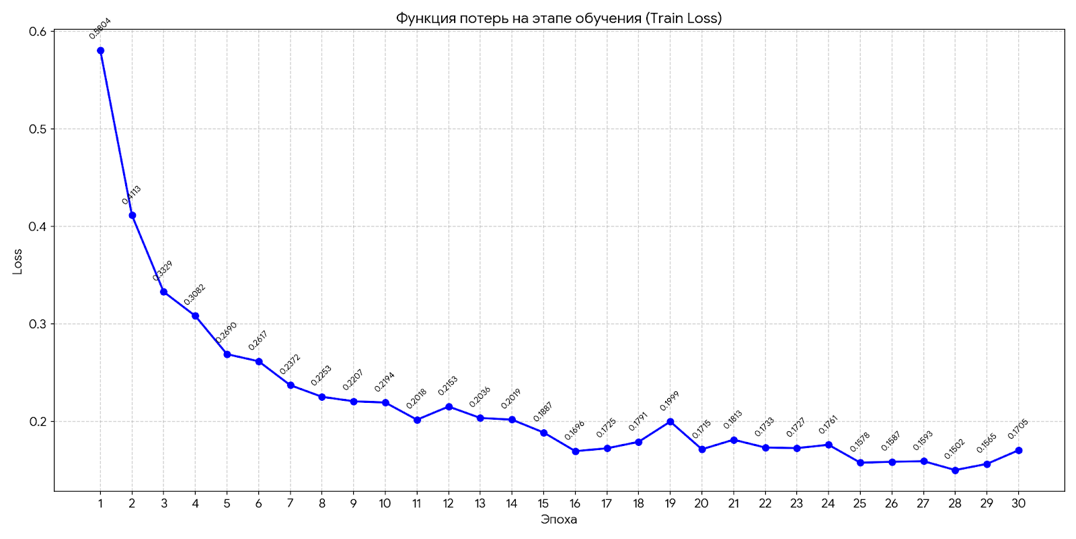

в качестве архитектуры был выбран универсальный U-Net с кодировщиком ResNet-34, а в качестве критерия оптимизации — комбинированный метод BCEWithLogitsLoss

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Inria_Project/unet_resnet34_inria.pth')

Теперь обученную модель импортируем из диска и попробую использовать в боевых задачах.


В компьютерном зрении часто используется метрика Intersection over Union(IoU) или метрику Жаккара.
Эта метрика берет площадь пересечения предсказанной маски с реальной разметкой и делит ее на площадь их объединения. Мы получаем честное число от 0 до 1, которое показывает, насколько точно совпали контуры.

Берём ранее сохраненные веса из Google Drive

In [ ]:
weights_path = '/content/drive/MyDrive/Inria_Project/unet_resnet34_inria.pth'
model.load_state_dict(torch.load(weights_path, map_location=device))

<All keys matched successfully>

**Проверка на адекватность(делаем на тренировочной выборке)**

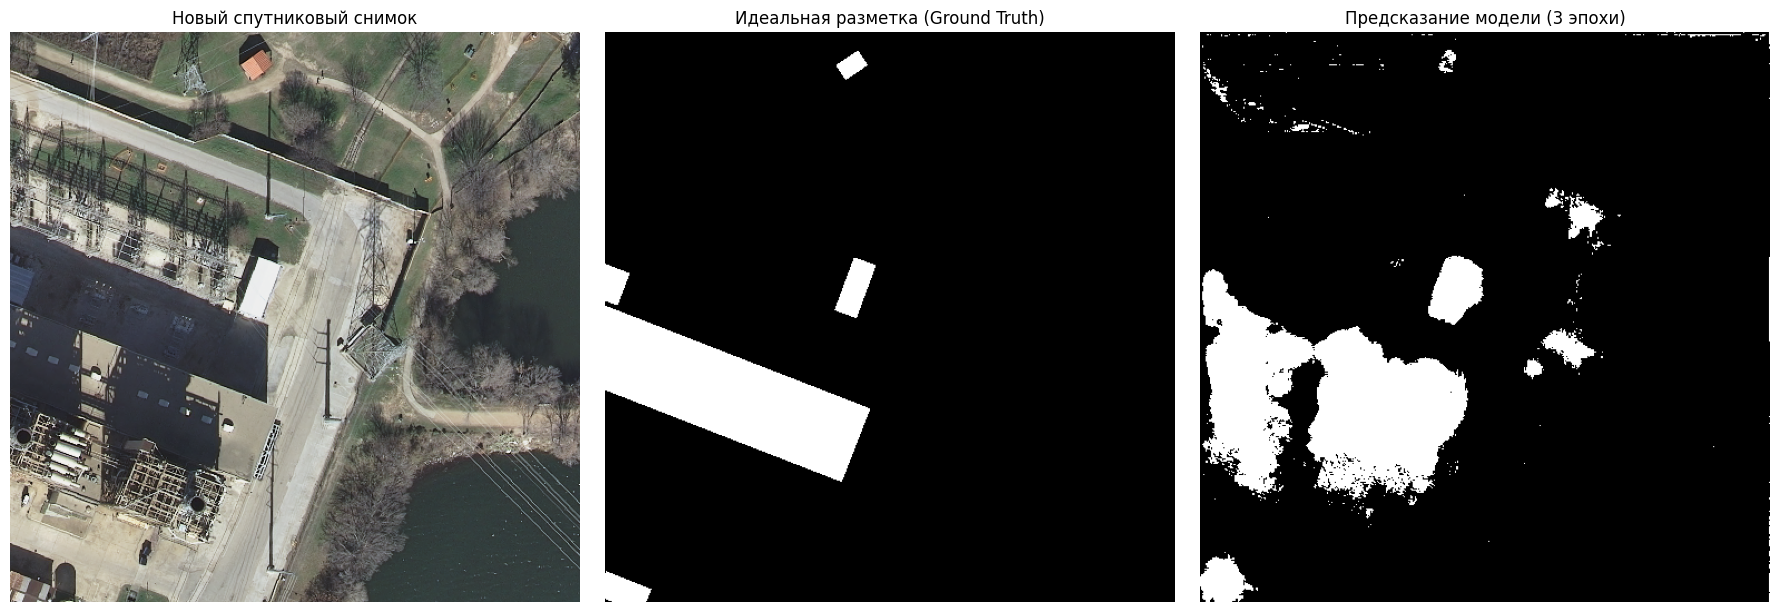

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Функция для генерации и отрисовки предсказаний
def visualize_unseen_image(dataset, trained_model, device, image_index=0):
    # Переводим сеть в режим тестирования
    trained_model.eval()

    # Достаем одну пару (картинка и маска) из загрузчика данных
    image_tensor, true_mask_tensor = dataset[image_index]

    # Подготавливаем картинку для нейросети
    input_batch = image_tensor.unsqueeze(0).to(device)

    # Отключаем расчет градиентов для экономии памяти
    with torch.no_grad():
        # Получаем сырые числа от нейросети
        raw_predictions = trained_model(input_batch)

        # Превращаем сырые числа в вероятности от 0 до 1
        probabilities = torch.sigmoid(raw_predictions)

        # Все, что больше 50% вероятности, считаем зданием (1), остальное фоном (0)
        predicted_mask = (probabilities > 0.5).float()

    # Подготовка к отрисовке: возвращаем картинке нормальные цвета
    mean_values = np.array([0.485, 0.456, 0.406])
    std_values = np.array([0.229, 0.224, 0.225])

    # Переводим тензор обратно в формат для matplotlib (Высота, Ширина, Каналы)
    image_numpy = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_numpy = (image_numpy * std_values + mean_values).clip(0, 1)

    # Убираем лишние размерности у масок
    true_mask_numpy = true_mask_tensor.squeeze(0).cpu().numpy()
    pred_mask_numpy = predicted_mask.squeeze(0).squeeze(0).cpu().numpy()

    # Отрисовка трех графиков в один ряд
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image_numpy)
    axes[0].set_title("Новый спутниковый снимок")
    axes[0].axis('off')

    axes[1].imshow(true_mask_numpy, cmap='gray')
    axes[1].set_title("Идеальная разметка (Ground Truth)")
    axes[1].axis('off')

    axes[2].imshow(pred_mask_numpy, cmap='gray')
    axes[2].set_title("Предсказание модели (3 эпохи)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# 2. Вызов функции для первого снимка из валидационной выборки
# Предполагается, что val_dataset, model и device уже инициализированы в памяти Colab
visualize_unseen_image(val_dataset, model, device, image_index=0)

In [ ]:
import random

# 1. Восстанавливаем тренировочный датасет для текущей сессии
# Берем первые 150 снимков (наши 85% от общего числа)
train_imgs = sorted([str(p) for p in images_dir.iterdir() if p.is_file()])[:150]
train_msks = sorted([str(p) for p in masks_dir.iterdir() if p.is_file()])[:150]

# Важный нюанс: для тестирования мы используем val_transform (с центральным кропом),
# чтобы картинки вырезались стабильно по центру, а не прыгали случайным образом, как при обучении.
train_dataset = InriaDataset(image_paths=train_imgs, mask_paths=train_msks, transform=val_transform)


# 2. Функция для массовой визуализации
def visualize_batch(dataset, trained_model, device, num_images=10):
    # Переводим сеть в режим оценки (замораживаем веса)
    trained_model.eval()

    # Чтобы не смотреть подряд на 10 одинаковых снимков одного города,
    # просим генератор случайных чисел выбрать 10 разных индексов из датасета
    indices = random.sample(range(len(dataset)), num_images)


    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

    # Стандартные константы для денормализации
    mean_values = np.array([0.485, 0.456, 0.406])
    std_values = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        # Запускаем цикл, который пройдет по каждому из 10 выбранных индексов
        for row_idx, data_idx in enumerate(indices):
            # Достаем картинку и маску
            image_tensor, true_mask_tensor = dataset[data_idx]

            # Добавляем размерность батча и отправляем на видеокарту
            input_batch = image_tensor.unsqueeze(0).to(device)

            # Делаем предсказание и переводим в нули и единицы
            raw_predictions = trained_model(input_batch)
            predicted_mask = (torch.sigmoid(raw_predictions) > 0.5).float()

            # Денормализация для отрисовки
            image_numpy = image_tensor.permute(1, 2, 0).cpu().numpy()
            image_numpy = (image_numpy * std_values + mean_values).clip(0, 1)
            true_mask_numpy = true_mask_tensor.squeeze(0).cpu().numpy()
            pred_mask_numpy = predicted_mask.squeeze(0).squeeze(0).cpu().numpy()

            # Отрисовка в конкретной строке (row_idx)
            axes[row_idx, 0].imshow(image_numpy)
            axes[row_idx, 0].axis('off')

            axes[row_idx, 1].imshow(true_mask_numpy, cmap='gray')
            axes[row_idx, 1].axis('off')

            axes[row_idx, 2].imshow(pred_mask_numpy, cmap='gray')
            axes[row_idx, 2].axis('off')

            # Ставим заголовки только для самого первого ряда, чтобы не дублировать текст
            if row_idx == 0:
                axes[row_idx, 0].set_title("Исходный снимок (Train)")
                axes[row_idx, 1].set_title("Идеальная разметка")
                axes[row_idx, 2].set_title("Предсказание модели")

    # Убираем лишние пустоты между картинками и выводим на экран
    plt.tight_layout()
    plt.show()

print("Генерация изображений... Это займет пару секунд.")
visualize_batch(train_dataset, model, device, num_images=10)

**Исходный снимок Test!**

In [ ]:
print("Запуск честного тестирования на отложенных данных (Validation)...")
# Передаем val_dataset вместо train_dataset для оценки реальной обобщающей способности
visualize_batch(val_dataset, model, device, num_images=10)

**Проверка лучшей модели(29 эпоха) на валидационной выборке!**

In [ ]:
import torch
import segmentation_models_pytorch as smp

# Определение аппаратного ускорителя для вычислений
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Инициализация структуры точно в такой же конфигурации, как при обучении
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,     # Предобученные веса ImageNet не загружаем, так как берем свои
    in_channels=3,
    classes=1
)

# Указание точного пути к файлу лучшей 29-й эпохи в Google Диске
weights_path = '/content/drive/MyDrive/Inria_Project/unet_resnet34_best.pth'

# Загрузка словаря весов и его сопоставление со структурой слоев нейросети
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

# Перенос весов на графический процессор и перевод в режим предсказания
model = model.to(device)
model.eval()

print("Архитектура инициализирована, веса лучшей 29-й эпохи успешно загружены.")

Архитектура инициализирована, веса лучшей 29-й эпохи успешно загружены.


Теперь убежусь, что это именно та самая модель

In [ ]:
# Извлечение ключей (названий слоев) из сохраненного файла контрольной точки
layer_names = list(state_dict.keys())

print(f"Всего обученных слоев в файле: {len(layer_names)}")
print(f"Первый слой кодировщика в файле: {layer_names[0]}")
print(f"Финальный сверточный слой в файле: {layer_names[-1]}")

# Проверка физического совпадения ключей модели и файла весов
model_keys = list(model.state_dict().keys())
if layer_names == model_keys:
    print("Успешно: Структура слоев в файле весов полностью идентична архитектуре модели!")
else:
    print("Внимание: Обнаружено расхождение в структуре слоев!")

Всего обученных слоев в файле: 278
Первый слой кодировщика в файле: encoder.conv1.weight
Финальный сверточный слой в файле: segmentation_head.0.bias
Успешно: Структура слоев в файле весов полностью идентична архитектуре модели!


Подсчёт метрики IoU

In [ ]:
import torch
from tqdm import tqdm

def calculate_validation_iou(model, data_loader, device='cuda'):
  '''
    Данная функция предназначена для работы с оригинальным валидационным подмножеством
    данных (летние снимки) и выполняет попиксельный расчет метрики Жаккара ($IoU$)
    для оценки базового качества сегментации застройки обученной моделью U-Net
    ResNet-34 перед проведением стресс-тестов на заснеженных кадрах.
  '''
    model.eval()
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in tqdm(data_loader, desc="Вычисление метрики IoU"):
            images = images.to(device)
            masks = masks.to(device).float()

            # Прямой проход модели и бинаризация предсказаний по нулевому порогу логитов
            outputs = model(images)
            preds = (outputs > 0.0).float()

            # Векторизованный расчет площади пересечения и объединения по всему батчу
            intersection = (preds * masks).sum(dim=(1, 2, 3))
            union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

            # Фильтрация деления на ноль с помощью константы малого значения
            batch_iou = (intersection + 1e-7) / (union + 1e-7)

            total_iou += batch_iou.mean().item()
            num_batches += 1

    return total_iou / num_batches

In [ ]:
# Запуск валидационного цикла
baseline_iou = calculate_validation_iou(model, val_loader, device=device)

print(f"\nБазовый IoU на летней валидационной выборке: {baseline_iou:.4f}")

Вычисление метрики IoU: 100%|██████████| 7/7 [01:48<00:00, 15.53s/it]


Базовый IoU на летней валидационной выборке: 0.7224


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_segmentation_with_metrics(model, data_loader, device='cuda', num_samples=10):
   '''
    функция, которая возьмет случайный батч из валидационной выборки, пропустит его
    через модель и выведет на один экран графические триптихи (исходный снимок,
    истинную маску и предсказание сети).
  '''
    model.eval()
    images_displayed = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)

            # Бинаризация логитов по нулевому порогу и перенос в NumPy
            preds = (outputs > 0.0).float().cpu().numpy()

            images = images.numpy()
            masks = masks.numpy()

            for i in range(images.shape[0]):
                if images_displayed >= num_samples:
                    return

                # Извлечение масок строго для текущего кадра
                gt_mask = masks[i, 0]
                pred_mask = preds[i, 0]

                # Локальный расчет площади пересечения и объединения
                intersection = np.sum(pred_mask * gt_mask)
                union = np.sum(pred_mask) + np.sum(gt_mask) - intersection

                # Расчет локального IoU с предохранителем от деления на ноль
                sample_iou = (intersection + 1e-7) / (union + 1e-7)

                # Денормализация исходного снимка для корректного отображения цветов
                img = np.transpose(images[i], (1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                # Инициализация графического окна
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                # Интеграция вычисленной метрики в главный заголовок триптиха
                fig.suptitle(f"Результат сегментации | Локальный IoU: {sample_iou:.4f}", fontsize=14, fontweight='bold')

                axes[0].imshow(img)
                axes[0].set_title("Исходный снимок")
                axes[0].axis('off')

                axes[1].imshow(gt_mask, cmap='gray')
                axes[1].set_title("Истинная маска (Ground Truth)")
                axes[1].axis('off')

                axes[2].imshow(pred_mask, cmap='gray')
                axes[2].set_title("Предсказание U-Net")
                axes[2].axis('off')

                plt.tight_layout()
                plt.show()

                images_displayed += 1

In [ ]:
#Тестирование на 10 снимках валидационной выборки(c метрикой Жаккара(она же IoU))
visualize_segmentation_with_metrics(model, val_loader, device=device, num_samples=10)

In [ ]:
# Борьба с ошибкой out of memory
import torch
import gc

# Принудительная сборка мусора и очистка кэша видеокарты
gc.collect()
torch.cuda.empty_cache()

print(f"Память GPU очищена. Свободно: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

Память GPU очищена. Свободно: 13.25 GB


In [ ]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# 1. ДОБАВЛЯЕМ RESIZE!
test_transforms = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_folder_path = '/content/drive/MyDrive/Inria_Project/unzip_full_archive/test/images'
# 2. Пересоздаем датасет с новыми трансформациями
test_dataset = InferenceDataset(test_folder_path, transform=test_transforms)

# 3. СНИЖАЕМ BATCH_SIZE ДО 1 (максимум до 2), чтобы гарантированно влезть в память
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print("test_loader обновлен: добавлен Resize(512x512), размер батча снижен до 1.")

test_loader обновлен: добавлен Resize(512x512), размер батча снижен до 1.


In [ ]:
# Для тестового датасета

import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_test_predictions_overlay(model, test_loader, device='cuda', num_samples=5):
    # Переводим модель в режим предсказания
    model.eval()
    images_displayed = 0

    with torch.no_grad():
        # Перебираем батчи из тестового даталоадера
        # Тестовый лоадер может возвращать только картинки или кортеж (изображения, имена_файлов)
        for batch in test_loader:
            if isinstance(batch, (tuple, list)):
                images = batch[0] # Берем только тензоры изображений
            else:
                images = batch

            images_gpu = images.to(device)
            outputs = model(images_gpu)

            # Бинаризация предсказаний по нулевому порогу
            preds = (outputs > 0.0).float().cpu().numpy()
            images_np = images.numpy()

            for i in range(images_np.shape[0]):
                if images_displayed >= num_samples:
                    return

                # Денормализация исходника для корректного отображения цветов
                img = np.transpose(images_np[i], (1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                pred_mask = preds[i, 0]

                # Создание полупрозрачного наложения (красный цвет для маски застройки)
                overlay = img.copy()
                color_mask = np.zeros_like(img)
                color_mask[:, :, 0] = 1.0  # Красный канал

                alpha = 0.5 # Прозрачность маски 50%
                mask_indices = pred_mask == 1.0

                # Смешивание пикселей: исходник + красная маска
                overlay[mask_indices] = img[mask_indices] * (1 - alpha) + color_mask[mask_indices] * alpha

                # Отрисовка графиков: строго два окна
                fig, axes = plt.subplots(1, 2, figsize=(14, 7))

                axes[0].imshow(img)
                axes[0].set_title("Исходный тестовый снимок", fontsize=14)
                axes[0].axis('off')

                axes[1].imshow(overlay)
                axes[1].set_title("Предсказание модели (Overlay)", fontsize=14)
                axes[1].axis('off')

                plt.tight_layout()
                plt.show()

                images_displayed += 1

СОЗДАНИЕ ТЕСТОВОГО МНОЖЕСТВА

In [ ]:
#Поскольку в тестовой папке Inria лежат только изображения без масок Ground Truth,
# нам нужен лаконичный класс датасета, который будет читать файлы и применять
# к ним наши трансформации.
import cv2
from torch.utils.data import Dataset

class InriaTestDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Читаем изображение с помощью OpenCV в формате BGR и переводим в RGB
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Применяем трансформации Albumentations(для корректного чтения изоб.)
        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image

In [ ]:
# Фиксируем путь к оригинальной текстовой папке (без масок)
test_images_dir = Path('/content/drive/MyDrive/Inria_Project/unzip_full_archive/test/images')
all_test_img_paths = sorted([str(p) for p in test_images_dir.iterdir() if p.is_file()])

# Для тестовой выборки используем ЦЕНТРАЛЬНОЕ кадрирование, как на валидации
test_transform = A.Compose([
    A.CenterCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Инициализируем тестовый датасет и loader
test_dataset = InriaTestDataset(image_paths=all_test_img_paths, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, drop_last=False)

print(f"Количество оригинальных снимков для теста: {len(all_test_img_paths)}")

Количество оригинальных снимков для теста: 180


In [ ]:
def visualize_test_center_crop_overlay(model, test_loader, device='cuda', num_samples=5):
    model.eval()
    images_displayed = 0

    with torch.no_grad():
        for images in test_loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)

            # Бинаризация предсказаний модели по нулевому порогу логитов
            preds = (outputs > 0.0).float().cpu().numpy()
            images_np = images.numpy()

            for i in range(images_np.shape[0]):
                if images_displayed >= num_samples:
                    return

                # Денормализация фрагмента для корректного восстановления цветов ImageNet
                img = np.transpose(images_np[i], (1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                pred_mask = preds[i, 0]

                # Создание полупрозрачного слоя маски (красный цвет заливки)
                overlay = img.copy()
                color_mask = np.zeros_like(img)
                color_mask[:, :, 0] = 1.0  # Активируем красный канал R в пространстве RGB

                alpha = 0.4 # Коэффициент прозрачности наложения
                mask_indices = pred_mask == 1.0
                overlay[mask_indices] = img[mask_indices] * (1 - alpha) + color_mask[mask_indices] * alpha

                # Отрисовка двух окон рядом в оригинальном масштабе 512x512
                fig, axes = plt.subplots(1, 2, figsize=(14, 7))

                axes[0].imshow(img)
                axes[0].set_title("Исходный тестовый фрагмент (CenterCrop)", fontsize=12)
                axes[0].axis('off')

                axes[1].imshow(overlay)
                axes[1].set_title("Предсказанные контуры крыш (Overlay)", fontsize=12)
                axes[1].axis('off')

                plt.tight_layout()
                plt.show()

                images_displayed += 1

In [ ]:
visualize_test_center_crop_overlay(model, test_loader, device=device, num_samples=15)